# Comparison analysis of multiple datasets with different cellular compositions

**Python package:** `CellChatPy`  
**Datasets:** embryonic mouse skin at E13.5 and E14.5  
**Input format:** AnnData (`.h5ad`)

This tutorial demonstrates how to compare cell-cell communication networks when
the datasets have related but non-identical cell populations. E13.5 and E14.5
share 11 populations, while `DC` and `Pericyte` occur only at E14.5. We infer
each network independently, lift E13.5 to the complete E14.5 group set, merge
the objects, and compare WNT signaling on a common visual scale.

The workflow follows the R CellChat vignette *Comparison analysis of multiple
datasets with different cellular compositions*, using the current CellChatPy
snake_case API and cells-by-genes data structure.



## Setup and imports

The setup cell locates the repository from either the project root or the
`tutorial` directory. Input and output paths are absolute `pathlib.Path` objects,
so later cells do not depend on the notebook kernel's working directory.



In [1]:
import pickle
import sys
import time
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

warnings.filterwarnings("ignore")

current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents) if (path / "CellChatPy").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "Could not locate the project root containing the CellChatPy package."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import CellChatPy as cc

DATA_DIR = (project_root / "data").resolve()
OUT_DIR = (project_root / "tutorial" / "figures_different_cellular_compositions").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
E13_PATH = DATA_DIR / "mouse_skin_e13.h5ad"
E14_PATH = DATA_DIR / "mouse_skin_e14.h5ad"
OUTPUT_PATH = project_root / "tutorial" / "cellchat_mouseSkin_E13_E14_from_h5.pkl"

def save_fig(fig, name):
    """Validate, save, display, and close one Matplotlib figure."""
    if fig is None:
        print(f"  [SKIP] {name} returned None")
        return None

    path = OUT_DIR / name
    try:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    except OSError as exc:
        raise OSError(
            f"Could not save figure to {str(path)!r}: {type(exc).__name__}: {exc}"
        ) from exc

    print(f"  Saved: {path}")
    plt.show()
    plt.close(fig)
    return None

print(f"Using CellChatPy from: {cc.__file__}")
print(f"CellChatPy version: {getattr(cc, '__version__', 'dev')}")
print(f"E13.5 input: {E13_PATH}")
print(f"E14.5 input: {E14_PATH}")
print(f"Figures will be saved to: {OUT_DIR}")



Using CellChatPy from: E:\Jin\cellchat.python_new\CellChatPy\__init__.py
CellChatPy version: 1.1.0
E13.5 input: E:\Jin\cellchat.python_new\data\mouse_skin_e13.h5ad
E14.5 input: E:\Jin\cellchat.python_new\data\mouse_skin_e14.h5ad
Figures will be saved to: E:\Jin\cellchat.python_new\tutorial\figures_different_cellular_compositions


---
## Part I: Prepare the two datasets

### Load the AnnData inputs

The two AnnData files contain normalized expression, cell names, gene names,
and cell metadata in CellChatPy's standard **cells x genes** layout. The
`cellchat_group` column supplies the biological cell-group identities.



In [2]:
ptm_total = time.time()

for input_path in (E13_PATH, E14_PATH):
    if not input_path.is_file():
        raise FileNotFoundError(f"Input AnnData file not found: {input_path}")

adata_e13 = ad.read_h5ad(E13_PATH)
adata_e14 = ad.read_h5ad(E14_PATH)

for dataset_name, adata in {"E13.5": adata_e13, "E14.5": adata_e14}.items():
    if "cellchat_group" not in adata.obs.columns:
        raise KeyError(f"{dataset_name} is missing adata.obs['cellchat_group'].")
    if not adata.obs_names.is_unique:
        raise ValueError(f"{dataset_name} contains duplicate cell names.")
    if not adata.var_names.is_unique:
        raise ValueError(f"{dataset_name} contains duplicate gene names.")

print(f"E13.5: {adata_e13.n_obs:,} cells x {adata_e13.n_vars:,} genes")
print(f"E14.5: {adata_e14.n_obs:,} cells x {adata_e14.n_vars:,} genes")

group_counts = pd.concat(
    {
        "E13.5": adata_e13.obs["cellchat_group"].value_counts(),
        "E14.5": adata_e14.obs["cellchat_group"].value_counts(),
    },
    axis=1,
).fillna(0).astype(int)
group_counts



E13.5: 12,951 cells x 18,322 genes
E14.5: 12,179 cells x 18,227 genes


,E13.5,E14.5
cellchat_group,,
FIB-A,4663,1944
FIB-P,2396,1805
FIB-B,1756,2221
Basal,1203,1385
Basal-P,937,1304
Muscle,896,654
MELA,433,311
MYL,274,320
Spinious,188,1396


### Create CellChat objects and set cell-group order

`create_cellchat` preserves the AnnData cell names, gene names, and metadata.
The explicit identity levels reproduce the biological order used in the source
vignette; this order also controls node placement in later figures.



In [3]:
cellchat_e13 = cc.create_cellchat(adata_e13, group_by="cellchat_group")
cellchat_e14 = cc.create_cellchat(adata_e14, group_by="cellchat_group")

e13_levels = [
    "FIB-A", "FIB-B", "FIB-P", "MYL", "Immune", "ENDO", "Muscle",
    "MELA", "Basal-P", "Basal", "Spinious",
]
e14_levels = [
    "FIB-A", "FIB-B", "FIB-P", "DC", "Pericyte", "MYL", "Immune",
    "ENDO", "Muscle", "MELA", "Basal-P", "Basal", "Spinious",
]

for dataset_name, adata, expected_levels in (
    ("E13.5", adata_e13, e13_levels),
    ("E14.5", adata_e14, e14_levels),
):
    observed = set(adata.obs["cellchat_group"].astype(str))
    expected = set(expected_levels)
    if observed != expected:
        raise ValueError(
            f"{dataset_name} cell groups do not match the tutorial levels. "
            f"Missing: {sorted(expected - observed)}; unexpected: {sorted(observed - expected)}"
        )

cellchat_e13 = cc.set_identity(cellchat_e13, group_by="cellchat_group", levels=e13_levels)
cellchat_e14 = cc.set_identity(cellchat_e14, group_by="cellchat_group", levels=e14_levels)

print("E13.5 cell groups:")
print(list(cellchat_e13.groups.categories))
print("\nE14.5 cell groups:")
print(list(cellchat_e14.groups.categories))



Create a CellChat object from an AnnData object
Using AnnData.obs as cell metadata
Cell groups used for CellChat analysis: ['Basal', 'Basal-P', 'ENDO', 'FIB-A', 'FIB-B', 'FIB-P', 'Immune', 'MELA', 'MYL', 'Muscle', 'Spinious']
Create a CellChat object from an AnnData object
Using AnnData.obs as cell metadata
Cell groups used for CellChat analysis: ['Basal', 'Basal-P', 'DC', 'ENDO', 'FIB-A', 'FIB-B', 'FIB-P', 'Immune', 'MELA', 'MYL', 'Muscle', 'Pericyte', 'Spinious']
E13.5 cell groups:
['FIB-A', 'FIB-B', 'FIB-P', 'MYL', 'Immune', 'ENDO', 'Muscle', 'MELA', 'Basal-P', 'Basal', 'Spinious']

E14.5 cell groups:
['FIB-A', 'FIB-B', 'FIB-P', 'DC', 'Pericyte', 'MYL', 'Immune', 'ENDO', 'Muscle', 'MELA', 'Basal-P', 'Basal', 'Spinious']


### Select the CellChat database

Use the mouse database and restrict the analysis to secreted signaling
interactions. The same database subset must be assigned to both objects before
their networks are inferred.



In [4]:
db_full = cc.load_database(species="mouse")
db_use = cc.subset_database(db_full, search="Secreted Signaling", key="annotation")

cellchat_e13 = cc.set_database(cellchat_e13, database=db_use)
cellchat_e14 = cc.set_database(cellchat_e14, database=db_use)

print(f"Mouse DB interactions used: {len(db_use['interaction'])}")



Mouse DB interactions used: 1280


---
## Part II: Infer communication networks independently

Each dataset is processed separately before any comparison is attempted. The
standard CellChatPy workflow subsets signaling genes, identifies overexpressed
genes and ligand-receptor interactions, estimates communication probabilities,
filters small cell populations, and aggregates interactions by pathway.

`n_boot=100` follows the full inference workflow and can take some time. Keep the
same random seed for both datasets to make the analysis reproducible.



In [5]:
n_boot = 100

inferred_objects = {}
for name, obj in {"E13.5": cellchat_e13, "E14.5": cellchat_e14}.items():
    dataset_start = time.time()
    print(f"\nRunning CellChatPy workflow for {name}")
    obj = cc.subset_signaling_data(obj)
    obj = cc.identify_overexpressed_genes(obj)
    obj = cc.identify_overexpressed_interactions(obj)
    obj = cc.compute_communication_probability(
        obj, type_method="triMean", n_boot=n_boot, seed_use=1
    )
    obj = cc.filter_communication(obj, min_cells=10)
    obj = cc.compute_pathway_probability(obj)
    obj = cc.aggregate_network(obj)
    inferred_objects[name] = obj
    print(f"Completed {name} in {time.time() - dataset_start:.1f} seconds")

cellchat_e13 = inferred_objects["E13.5"]
cellchat_e14 = inferred_objects["E14.5"]

print("\nE13.5 pathways:")
print(list(cellchat_e13.pathway_network["prob"]))
print("\nE14.5 pathways:")
print(list(cellchat_e14.pathway_network["prob"]))




Running CellChatPy workflow for E13.5
The number of highly variable ligand-receptor pairs used for signaling inference is 846
triMean is used for calculating the average gene expression per cell group.
Pre-computing 100 bootstrap averaged expressions...
Computing communication probabilities for 846 LR pairs...
>>> CellChat inference is done.
Results stored in .network.
Pathway-level results stored in .pathway_network.
Completed E13.5 in 139.7 seconds

Running CellChatPy workflow for E14.5
The number of highly variable ligand-receptor pairs used for signaling inference is 871
triMean is used for calculating the average gene expression per cell group.
Pre-computing 100 bootstrap averaged expressions...
Computing communication probabilities for 871 LR pairs...
>>> CellChat inference is done.
Results stored in .network.
Pathway-level results stored in .pathway_network.
Completed E14.5 in 165.2 seconds

E13.5 pathways:
['MK', 'PTN', 'GALECTIN', 'WNT', 'ncWNT', 'ANGPTL', 'PDGF', 'IGF', 'TGF

---
## Part III: Lift and merge the CellChat objects

Comparative visualizations require a common sender-receiver axis. Because E14.5
contains every E13.5 group plus `DC` and `Pericyte`, its ordered levels define
the common group set. `lift_cellchat` adds zero-valued rows and columns for the
two groups absent from E13.5 without inventing expression or interactions.

> The order of `group_new` determines the cell-group order in comparative plots.
> If different datasets each contain unique groups, construct an ordered union
> instead of borrowing the levels from only one dataset.



In [6]:
group_new = list(cellchat_e14.groups.categories)
missing_from_e14 = [group for group in cellchat_e13.groups.categories if group not in group_new]
if missing_from_e14:
    raise ValueError(
        "E14.5 does not contain every E13.5 group; build an ordered union for group_new. "
        f"Missing groups: {missing_from_e14}"
    )

cellchat_e13 = cc.lift_cellchat(cellchat_e13, group_new=group_new)

object_list = {"E13.5": cellchat_e13, "E14.5": cellchat_e14}
cellchat = cc.merge_cellchat(
    list(object_list.values()),
    add_names=list(object_list.keys()),
    cell_prefix=True,
)

print("Lifted E13.5 cell groups:")
print(list(cellchat_e13.groups.categories))
print("\nMerged datasets:")
print(list(cellchat.network))



Lifting CellChat object using cell labels: FIB-A, FIB-B, FIB-P, DC, Pericyte, MYL, Immune, ENDO, Muscle, MELA, Basal-P, Basal, Spinious
Merging signaling expression, metadata, spatial data, and dataset networks
Lifted E13.5 cell groups:
['FIB-A', 'FIB-B', 'FIB-P', 'DC', 'Pericyte', 'MYL', 'Immune', 'ENDO', 'Muscle', 'MELA', 'Basal-P', 'Basal', 'Spinious']

Merged datasets:
['E13.5', 'E14.5']


---
## Part IV: Compare WNT signaling

WNT is the example pathway used by the original vignette. Before plotting, we
verify that WNT was inferred in both datasets and compute one shared maximum
edge weight. Using a common scale prevents the same line width from representing
different communication strengths in E13.5 and E14.5.



In [7]:
pathways_show = "WNT"

for name, obj in object_list.items():
    available_pathways = list(obj.pathway_network.get("prob", {}))
    if pathways_show not in available_pathways:
        raise ValueError(
            f"{pathways_show} was not inferred in {name}. "
            f"Available pathways: {available_pathways}"
        )

weight_max = max(
    float(cc.aggregate_signaling_matrix(obj, signaling=pathways_show).max())
    for obj in object_list.values()
)
if weight_max <= 0:
    raise ValueError("WNT has no significant communication strength to visualize.")

print(f"Shared maximum WNT edge weight: {weight_max:.6g}")



Shared maximum WNT edge weight: 0.0659105


### Circle plot

The circle layout shows every lifted cell group around a common ring. Directed
edges connect sender groups to receiver groups, while the shared `weight_max`
makes edge widths comparable between developmental stages.



  Saved: E:\Jin\cellchat.python_new\tutorial\figures_different_cellular_compositions\01_circle_WNT_E13.5.png


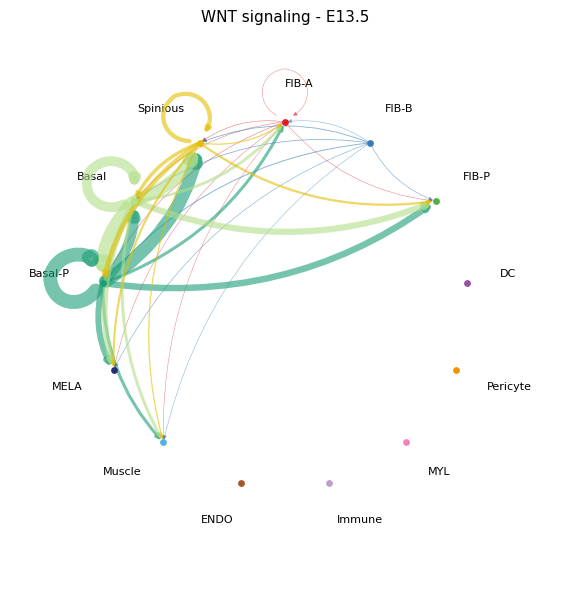

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_different_cellular_compositions\01_circle_WNT_E14.5.png


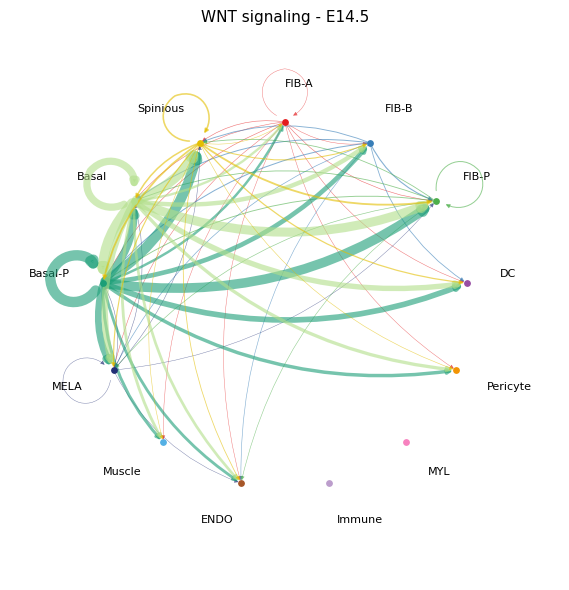

In [8]:
for name, obj in object_list.items():
    fig = cc.plot_network_aggregate(
        obj,
        signaling=pathways_show,
        layout="circle",
        edge_weight_max=weight_max,
        edge_width_max=10,
        title_name=f"{pathways_show} signaling - {name}",
        return_fig=True,
    )
    save_fig(fig, f"01_circle_WNT_{name}.png")



### Hierarchy plot

The first ten groups in `group_new` are dermal populations and are selected as
receivers in the left hierarchy panel. The complementary epidermal populations
appear in the right panel. CellChatPy uses zero-based indices, hence
`range(10)` corresponds to the first ten groups.



  Saved: E:\Jin\cellchat.python_new\tutorial\figures_different_cellular_compositions\02_hierarchy_WNT_E13.5.png


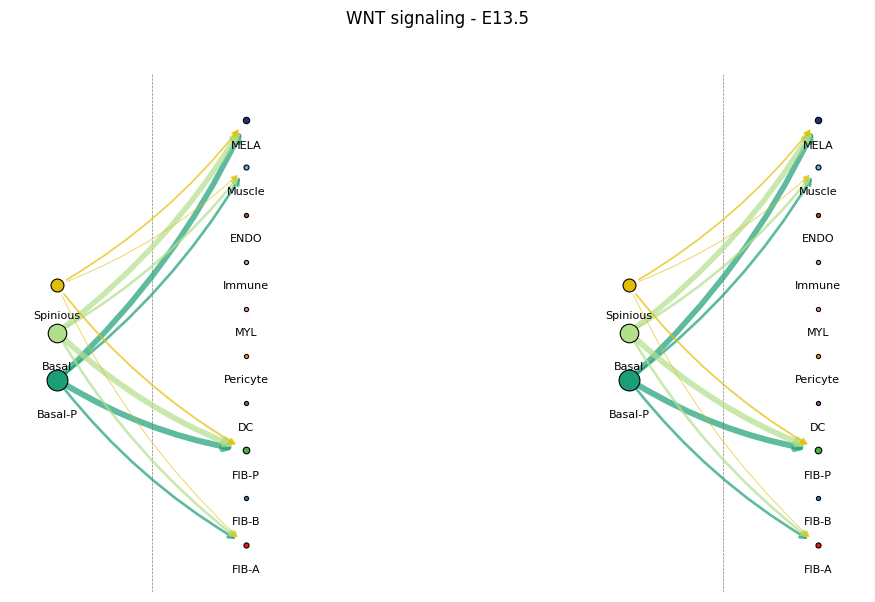

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_different_cellular_compositions\02_hierarchy_WNT_E14.5.png


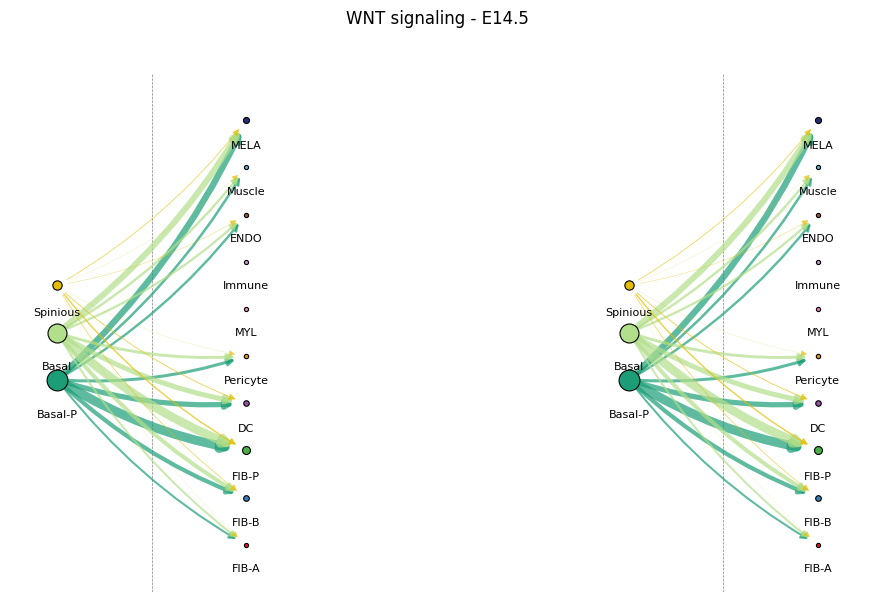

In [9]:
vertex_receiver = list(range(10))

for name, obj in object_list.items():
    fig = cc.plot_network_aggregate(
        obj,
        signaling=pathways_show,
        layout="hierarchy",
        vertex_receiver=vertex_receiver,
        edge_weight_max=weight_max,
        edge_width_max=10,
        title_name=f"{pathways_show} signaling - {name}",
        fig_size=(14, 6),
        return_fig=True,
    )
    save_fig(fig, f"02_hierarchy_WNT_{name}.png")



### Chord diagram

The chord layout emphasizes reciprocal signaling and the overall connectivity
between individual cell groups. It visualizes the same aggregated WNT matrix as
the circle plot.



  Saved: E:\Jin\cellchat.python_new\tutorial\figures_different_cellular_compositions\03_chord_WNT_E13.5.png


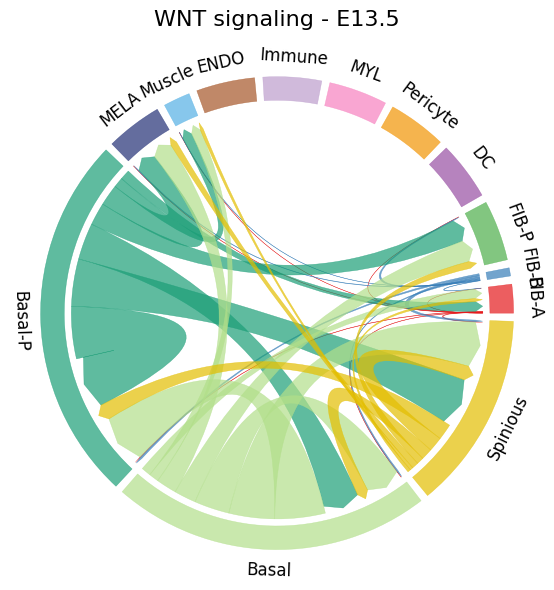

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_different_cellular_compositions\03_chord_WNT_E14.5.png


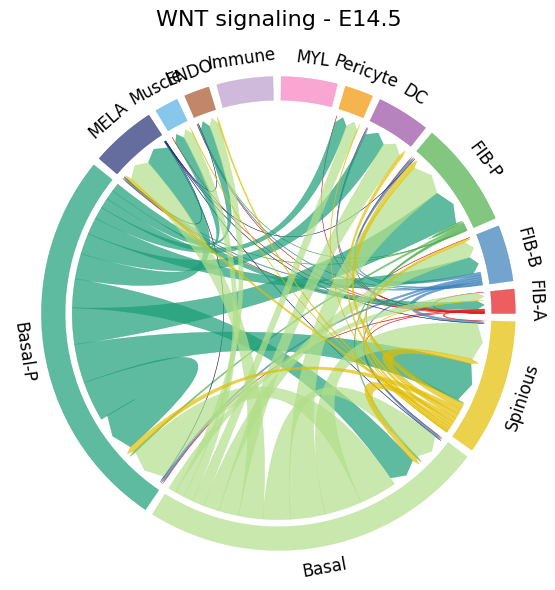

In [10]:
for name, obj in object_list.items():
    fig = cc.plot_network_aggregate(
        obj,
        signaling=pathways_show,
        layout="chord",
        edge_weight_max=weight_max,
        edge_width_max=10,
        title_name=f"{pathways_show} signaling - {name}",
        return_fig=True,
    )
    save_fig(fig, f"03_chord_WNT_{name}.png")



### Chord diagram grouped by tissue compartment

To summarize communication above the cell-group level, map the first ten groups
to `Dermal` and the remaining three to `Epidermal`.



In [11]:
if len(group_new) != 13:
    raise ValueError(
        f"This tutorial expects 13 lifted groups, but found {len(group_new)}."
    )

compartment_by_group = {
    group: "Dermal" if index < 10 else "Epidermal"
    for index, group in enumerate(group_new)
}

pd.Series(compartment_by_group, name="compartment").to_frame()



,compartment
FIB-A,Dermal
FIB-B,Dermal
FIB-P,Dermal
DC,Dermal
Pericyte,Dermal
MYL,Dermal
Immune,Dermal
ENDO,Dermal
Muscle,Dermal
MELA,Dermal


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_different_cellular_compositions\04_chord_grouped_WNT_E13.5.png


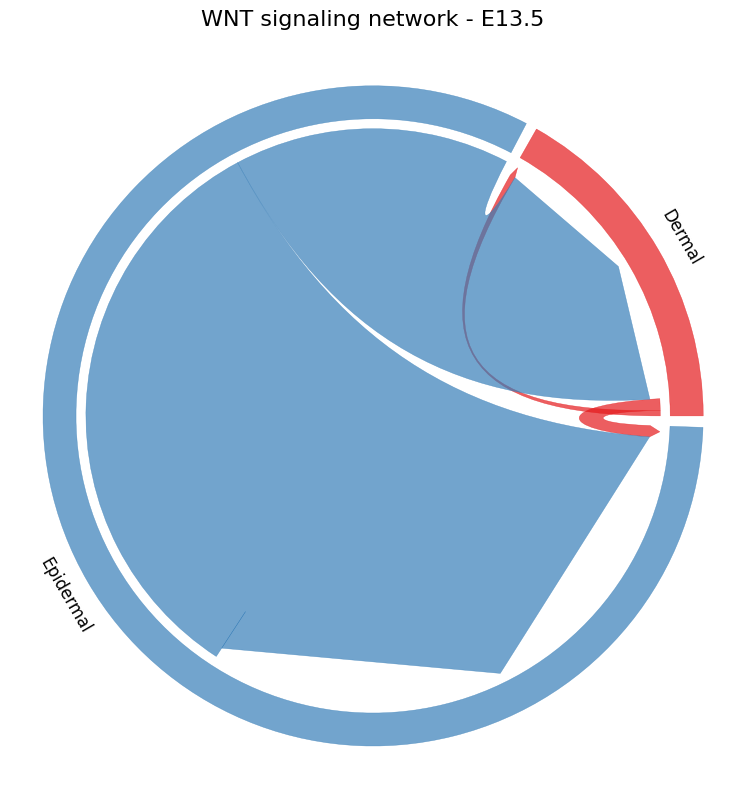

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_different_cellular_compositions\04_chord_grouped_WNT_E14.5.png


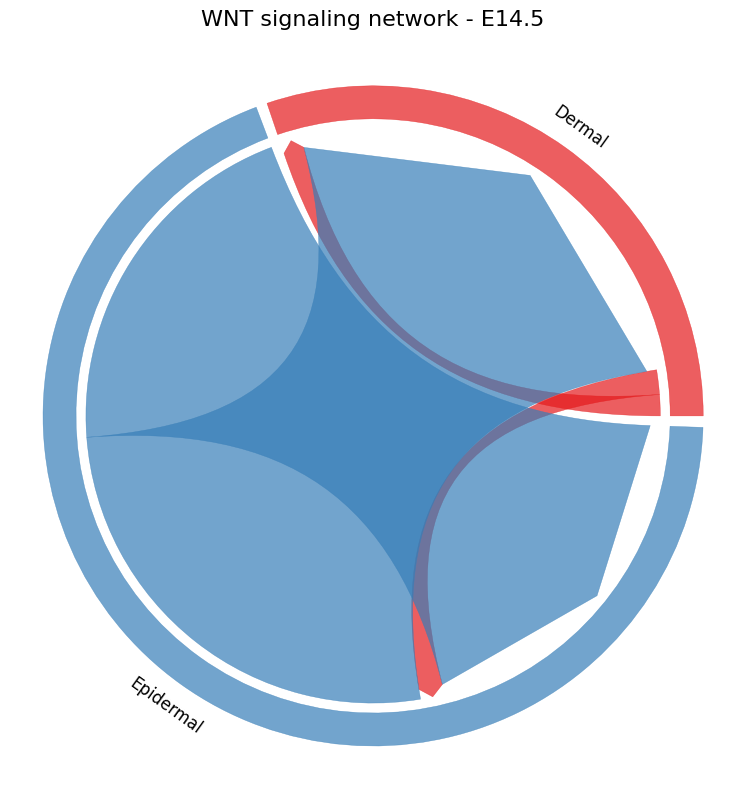

In [12]:
for name, obj in object_list.items():
    fig = cc.plot_network_chord_cell(
        obj,
        signaling=pathways_show,
        group=compartment_by_group,
        title_name=f"{pathways_show} signaling network - {name}",
        return_fig=True,
    )
    save_fig(fig, f"04_chord_grouped_WNT_{name}.png")



---
## Part V: When cellular compositions differ substantially

Lifting supports comparison when datasets differ by a limited number of groups,
as in this example. When most cell populations differ, methods that depend on
one-to-one sender and receiver identities are not directly interpretable.

- Do not directly compare differential interaction counts or strengths between
  unmatched cell populations. Plot each dataset's interaction network separately.
- Do not use functional pathway similarity unless the sender and receiver group
  identities are comparable across datasets.
- Structural pathway similarity remains appropriate because it compares network
  topology rather than requiring identical cell labels.



---
## Save the analysis objects

Store both lifted single-dataset objects together with the merged object. This
allows downstream comparison without rerunning the bootstrap inference.



In [13]:
with OUTPUT_PATH.open("wb") as handle:
    pickle.dump(
        {
            "cellchat_e13": cellchat_e13,
            "cellchat_e14": cellchat_e14,
            "cellchat_merged": cellchat,
        },
        handle,
    )

print(f"Saved CellChat objects to: {OUTPUT_PATH}")
print(f"Total runtime: {time.time() - ptm_total:.1f} seconds")


Saved CellChat objects to: E:\Jin\cellchat.python_new\tutorial\cellchat_mouseSkin_E13_E14_from_h5.pkl
Total runtime: 313.8 seconds
